# Risco de atraso em pedidos da Olist

## Desafio de negócio

Identificar, **logo após a aprovação do pagamento**, quais pedidos possuem maior risco de serem entregues depois do prazo prometido. A análise mantém uma linha por pedido e investiga cinco hipóteses sobre desbalanceamento, prazo, complexidade, geografia e sazonalidade.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").is_file()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from module_olist.eda import (
    build_order_analysis, complexity_summary, deadline_risk,
    load_olist_tables, monthly_risk, seller_risk, state_risk, target_summary,
)

sns.set_theme(style="whitegrid", palette="Blues_r")

2026-08-24 15:23:44.514 | INFO     | module_olist.config:<module>:11 - PROJ_ROOT path is: C:\Users\Administrador\Desktop\machine_learning_2026.2\olist


## 1. Instante da previsão e risco de data leakage

O modelo deverá prever no instante `order_approved_at`. Datas de envio e entrega, avaliações, comentários e qualquer status posterior são informações futuras e não podem ser features. A data real da entrega é usada somente para construir o target histórico `is_late`.

In [2]:
orders, items, customers = load_olist_tables(PROJECT_ROOT / "data" / "raw")
orders_analysis = build_order_analysis(orders, items, customers)

print(f"Pedidos originais: {len(orders):,}")
print(f"Pedidos no recorte histórico: {len(orders_analysis):,}")
print(f"Uma linha por pedido: {orders_analysis['order_id'].is_unique}")
orders_analysis.head()

Pedidos originais: 99,441
Pedidos no recorte histórico: 96,456
Uma linha por pedido: True


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_late,item_count,seller_count,total_price,total_freight,customer_state,customer_city,promised_days,purchase_month,purchase_weekday,purchase_hour
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,0,1,1,29.99,8.72,SP,sao paulo,15.536632,10,0,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,0,1,1,118.70,22.76,BA,barreiras,17.858021,7,1,20
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,0,1,1,159.90,19.22,GO,vianopolis,26.628206,8,2,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,0,1,1,45.00,27.20,RN,sao goncalo do amarante,26.176400,11,5,19
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,0,1,1,19.90,8.72,SP,santo andre,12.069109,2,1,21


## 2. Qual é a frequência de pedidos atrasados?

**Hipótese:** os atrasos são minoritários, produzindo desbalanceamento entre as classes.

,pedidos,percentual
situacao,,
No prazo,88630,91.89
Atrasado,7826,8.11


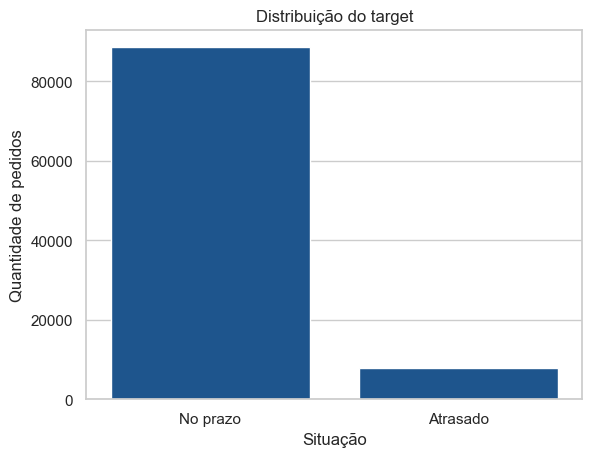

In [3]:
target = target_summary(orders_analysis)
display(target)
ax = sns.barplot(data=target.reset_index(), x="situacao", y="pedidos")
ax.set(xlabel="Situação", ylabel="Quantidade de pedidos", title="Distribuição do target")
plt.show()

**Conclusão:** a taxa de atraso é **8,11%**. A hipótese foi apoiada; um classificador que sempre previsse “no prazo” teria 91,89% de acurácia e ainda seria inútil para detectar atrasos. Métricas como recall, precision, F1 e PR-AUC serão necessárias.

## 3. Pedidos com prazos menores atrasam mais?

**Hipótese:** prazos curtos oferecem menos margem para problemas logísticos.

,promised_days_group,pedidos,taxa_atraso
0,Até 7,1637,28.34
1,8–14,11531,6.76
2,15–21,25185,9.07
3,22–30,39681,8.32
4,Mais de 30,18416,5.38


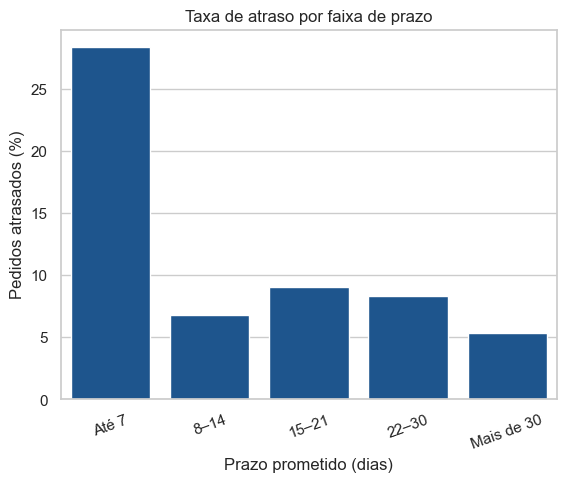

In [4]:
deadlines = deadline_risk(orders_analysis)
display(deadlines.round(2))
ax = sns.barplot(data=deadlines, x="promised_days_group", y="taxa_atraso")
ax.set(xlabel="Prazo prometido (dias)", ylabel="Pedidos atrasados (%)", title="Taxa de atraso por faixa de prazo")
plt.xticks(rotation=20)
plt.show()

**Conclusão:** a hipótese foi parcialmente apoiada. Pedidos com prazo de até 7 dias chegam a **28,34%** de atraso, mas a taxa não cai de modo perfeitamente monotônico nas demais faixas. `promised_days` é uma candidata forte a feature, após tratar os seis prazos não positivos.

## 4. Pedidos maiores ou mais complexos atrasam mais?

**Hipótese:** mais itens ou vendedores aumentam a complexidade logística e o risco.

,item_count,seller_count,total_price,total_freight
is_late,,,,
No prazo,1.0,1.0,85.5,17.07
Atrasado,1.0,1.0,89.9,18.06


,seller_group,pedidos,taxa_atraso
0,Mais de um,1275,1.41
1,Um vendedor,95181,8.20


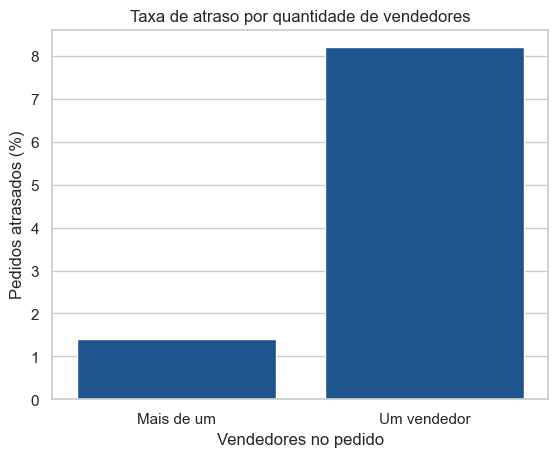

In [5]:
display(complexity_summary(orders_analysis).round(2))
sellers = seller_risk(orders_analysis)
display(sellers.round(2))
ax = sns.barplot(data=sellers, x="seller_group", y="taxa_atraso")
ax.set(xlabel="Vendedores no pedido", ylabel="Pedidos atrasados (%)", title="Taxa de atraso por quantidade de vendedores")
plt.show()

**Conclusão:** a hipótese não foi apoiada para quantidade de vendedores. Pedidos com um vendedor atrasaram 8,20%, contra 1,41% para pedidos com vários vendedores. As medianas de itens e vendedores são iguais entre as classes, e a diferença de preço/frete é pequena.

## 5. O risco varia geograficamente?

**Hipótese:** distância e infraestrutura logística produzem riscos diferentes. Para reduzir instabilidade, entram apenas estados com pelo menos 100 pedidos.

,customer_state,pedidos,taxa_atraso
0,AL,397,23.93
1,MA,716,19.69
2,PI,476,15.97
3,CE,1278,15.34
4,SE,335,15.22
5,BA,3256,14.04
6,RJ,12348,13.48
7,TO,274,12.77
8,PA,946,12.37
9,ES,1995,12.23


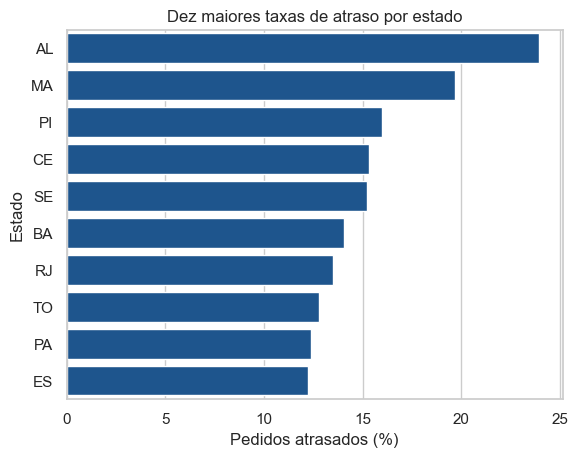

In [6]:
states = state_risk(orders_analysis, min_orders=100)
display(states.head(10).round(2))
ax = sns.barplot(data=states.head(10), x="taxa_atraso", y="customer_state")
ax.set(xlabel="Pedidos atrasados (%)", ylabel="Estado", title="Dez maiores taxas de atraso por estado")
plt.show()

**Conclusão:** localização está fortemente associada ao target: AL (23,93%) e MA (19,69%) ficam muito acima da média geral. Estado é uma feature potencial, mas pode representar variáveis não observadas como distância, malha logística e distribuição de vendedores.

## 6. O momento da compra está associado ao atraso?

**Hipótese:** determinados meses enfrentam maior pressão logística.

,purchase_month,pedidos,taxa_atraso
0,1,7817,6.23
1,2,8196,13.43
2,3,9549,17.15
3,4,9101,5.96
4,5,10294,6.64
5,6,9231,2.21
6,7,10028,4.08
7,8,10544,7.58
8,9,4151,5.23
9,10,4743,5.06


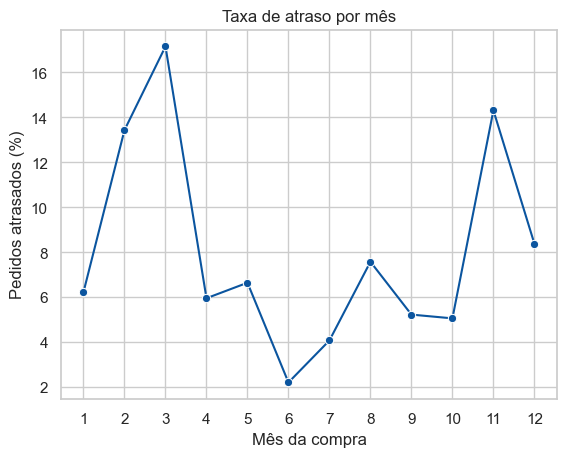

In [7]:
months = monthly_risk(orders_analysis)
display(months.round(2))
ax = sns.lineplot(data=months, x="purchase_month", y="taxa_atraso", marker="o")
ax.set(xticks=range(1, 13), xlabel="Mês da compra", ylabel="Pedidos atrasados (%)", title="Taxa de atraso por mês")
plt.show()

**Conclusão:** há variação temporal, com picos em março (17,15%) e novembro (14,31%) e mínimo em junho (2,21%). Isso ainda não prova sazonalidade, pois meses de anos diferentes foram agrupados e os volumes variam.

## Próximos passos

As candidatas iniciais são `promised_days`, localização do cliente, mês/dia/hora da compra, preço, frete, itens e vendedores. Antes da modelagem, é necessário definir a divisão temporal, codificar categorias e avaliar métricas adequadas ao desbalanceamento sem incluir informação posterior à aprovação.